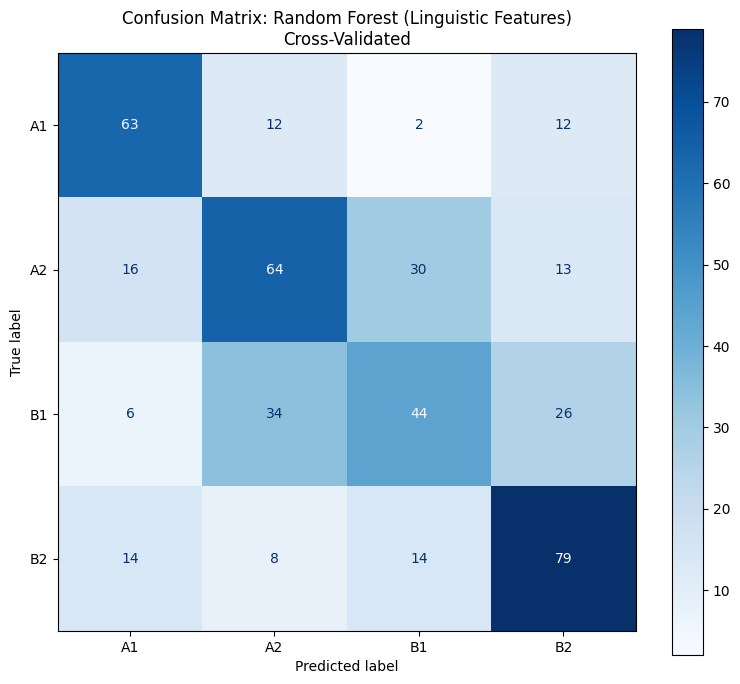


===== CLASSIFICATION REPORT (RANDOM FOREST) =====
              precision    recall  f1-score   support

          A1       0.64      0.71      0.67        89
          A2       0.54      0.52      0.53       123
          B1       0.49      0.40      0.44       110
          B2       0.61      0.69      0.64       115

    accuracy                           0.57       437
   macro avg       0.57      0.58      0.57       437
weighted avg       0.57      0.57      0.57       437



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

df = pd.read_csv("data_v1.csv")
df = df[df["Level"].isin(["A1", "A2", "B1", "B2"])]

# features
lexical = ["average_token_length_chars", "average_syllables_per_token", "total_tokens", "unique_tokens", "unique_lemmas", "hapax_legomena", "mattr_tokens", "mattr_lemmas"]
pos = ["pos_frequencies_NOUN", "pos_frequencies_VERB", "pos_frequencies_ADJF", "pos_frequencies_PREP", "pos_frequencies_PRCL", "pos_frequencies_NPRO", "pos_frequencies_CONJ", "pos_frequencies_ADVB", "pos_frequencies_NUMR", "pos_frequencies_X", "pos_frequencies_GRND", "service_word_count"]
sentence = ["sentence_token_stats_mean", "sentence_token_stats_median", "sentence_token_stats_min", "sentence_token_stats_max", "sentence_char_stats_mean", "sentence_char_stats_median", "sentence_char_stats_min", "sentence_char_stats_max"]
syntactic = ["avg_clauses", "avg_tree_depths"]

all_features = lexical + pos + sentence + syntactic

X = df[all_features]
y = df["Level"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=300, random_state=42))
])

y_pred_cv = cross_val_predict(rf_pipeline, X, y_encoded, cv=cv)

cm = confusion_matrix(y_encoded, y_pred_cv)
fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues", ax=ax, values_format='d')
plt.title("Confusion Matrix: Random Forest (Linguistic Features)\nCross-Validated", fontsize=12)
plt.tight_layout()
plt.savefig("cm_random_forest.png", dpi=300)
plt.show()

print("\n===== CLASSIFICATION REPORT (RANDOM FOREST) =====")
print(classification_report(y_encoded, y_pred_cv, target_names=le.classes_))

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

feature_cols = lexical + pos + sentence + syntactic
X = df[feature_cols]
y = y_encoded

models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=300, random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_list = []

print("Starting experiments...")

for name, model in models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline, X, y, cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    )

    results_list.append({
        "Model": name,
        "Accuracy": scores['test_accuracy'].mean(),
        "Precision (M)": scores['test_precision_macro'].mean(),
        "Recall (M)": scores['test_recall_macro'].mean(),
        "F1 (Macro)": scores['test_f1_macro'].mean()
    })

final_table = pd.DataFrame(results_list).sort_values("F1 (Macro)", ascending=False).round(3)

print("\n===== FINAL RESULTS FOR LATEX TABLE =====")
print(final_table.to_string(index=False))

Starting experiments...

===== FINAL RESULTS FOR LATEX TABLE =====
             Model  Accuracy  Precision (M)  Recall (M)  F1 (Macro)
      RandomForest     0.572          0.575       0.579       0.571
  GradientBoosting     0.529          0.530       0.533       0.527
               SVM     0.508          0.522       0.507       0.495
LogisticRegression     0.501          0.506       0.499       0.492
